# **Análisis Predictivo de Ventas por Categoría de Producto**

# 1. OBTENCIÓN DE DATOS DESDE KAGGLE

En esta sección se configura el acceso a la API de Kaggle desde Google Colab mediante el archivo de credenciales kaggle.json`.

Este paso permite acceder a datasets públicos de manera reproducible y automatizada.

**NOTA:**
Este procedimiento debe ejecutarse una única vez por sesión.
Tras la carga del archivo, se recomienda reiniciar el entorno de ejecución para aplicar correctamente la configuración.


In [ ]:
from google.colab import files
import os
import shutil

print("Sube tu archivo 'kaggle.json' descargado desde Kaggle.")
uploaded = files.upload()

if "kaggle.json" in uploaded:
    # Crear directorio de configuración de Kaggle
    kaggle_dir = os.path.expanduser("~/.kaggle")
    os.makedirs(kaggle_dir, exist_ok=True)

    # Definir rutas
    source_path = "kaggle.json"
    target_path = os.path.join(kaggle_dir, "kaggle.json")

    # Mover archivo a la ubicación correcta
    shutil.move(source_path, target_path)

    # Asignar permisos seguros
    os.chmod(target_path, 0o600)

    print("\nArchivo 'kaggle.json' configurado correctamente.")
    print("IMPORTANTE: Reinicia la sesión de Colab antes de continuar.")
else:
    print("No se subió el archivo 'kaggle.json'. Inténtalo de nuevo.")

Sube tu archivo 'kaggle.json' descargado desde Kaggle.


Saving kaggle.json to kaggle.json

Archivo 'kaggle.json' configurado correctamente.
IMPORTANTE: Reinicia la sesión de Colab antes de continuar.


# Explicación Técnica del paso:

- El archivo `kaggle.json` contiene las credenciales de acceso a la API de Kaggle.

- Se almacena en la ruta `~/.kaggle/kaggle.json`, que es la ubicación esperada por la librería oficial.

- Los permisos `0o600` garantizan que solo el usuario actual tenga acceso al archivo, cumpliendo con los requisitos de seguridad de Kaggle.

- Una vez completado este paso, es necesario reiniciar el entorno para habilitar correctamente la autenticación.

# 2. VERIFICACIÓN DE LA CONFIGURACIÓN DE KAGGLE

Se valida que el archivo `kaggle.json` se encuentre en la ruta correcta y que tenga los permisos adecuados.

In [ ]:
import os

kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")

if os.path.exists(kaggle_json_path):
    print(f"El archivo existe en: {kaggle_json_path}")

    permissions = oct(os.stat(kaggle_json_path).st_mode & 0o777)
    print(f"Permisos actuales: {permissions}")

    if permissions == "0o600":
        print("La configuración de Kaggle es correcta.")
    else:
        print("Advertencia: los permisos no son los esperados (0o600).")
else:
    print("No se encontró el archivo 'kaggle.json'.")

El archivo existe en: /root/.kaggle/kaggle.json
Permisos actuales: 0o600
La configuración de Kaggle es correcta.


# 3. PREPARACIÓN DEL ENTORNO DE TRABAJO

Se crea una carpeta local para almacenar archivos descargados y resultados intermedios del análisis.



In [ ]:
import os

os.makedirs("data", exist_ok=True)
print("Carpeta 'data' lista para trabajar.")

Carpeta 'data' lista para trabajar.


# 4. LIBRERÍAS PARA CARGA Y MANEJO DE DATOS

En esta fase únicamente se cargan librerías relacionadas con la obtención y manipulación inicial de datos.

Las librerías específicas de modelado se incorporarán en secciones posteriores del notebook.




In [ ]:
!pip install -q kagglehub[pandas-datasets]

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib

import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 100

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 5. CARGA DEL DATASET

Se carga el dataset `customer_shopping_data.csv` desde Kaggle.

Este dataset contiene información transaccional de ventas, incluyendo variables como fecha, categoría de producto, cantidad y precio.



In [ ]:
file_path = "customer_shopping_data.csv"

df_empresa = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mehmettahiraslan/customer-shopping-dataset",
    file_path
)

print("Dataset cargado correctamente.")
print("\nPrimeras 5 filas:")
display(df_empresa.head())

Using Colab cache for faster access to the 'customer-shopping-dataset' dataset.
Dataset cargado correctamente.

Primeras 5 filas:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon



# 6. INSPECCIÓN INICIAL DEL DATASET

Se realiza una revisión preliminar del dataset para analizar:
- Dimensiones
- Tipos de variables
- Presencia de valores nulos



In [ ]:
print("Dimensiones del dataset:", df_empresa.shape)

print("\nTipos de datos:")
print(df_empresa.dtypes)

print("\nValores nulos por columna:")
print(df_empresa.isnull().sum())

Dimensiones del dataset: (99457, 10)

Tipos de datos:
invoice_no         object
customer_id        object
gender             object
age                 int64
category           object
quantity            int64
price             float64
payment_method     object
invoice_date       object
shopping_mall      object
dtype: object

Valores nulos por columna:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


In [ ]:
# Resumen estadístico general
df_empresa.describe(include="all")

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
count,99457,99457,99457,99457.000000,99457,99457.000000,99457.000000,99457,99457,99457
unique,99457,99457,2,NaN,8,NaN,NaN,3,797,10
top,I232867,C273973,Female,NaN,Clothing,NaN,NaN,Cash,24/11/2021,Mall of Istanbul
freq,1,1,59482,NaN,34487,NaN,NaN,44447,159,19943
mean,NaN,NaN,NaN,43.427089,NaN,3.003429,689.256321,NaN,NaN,NaN
std,NaN,NaN,NaN,14.990054,NaN,1.413025,941.184567,NaN,NaN,NaN
min,NaN,NaN,NaN,18.000000,NaN,1.000000,5.230000,NaN,NaN,NaN
25%,NaN,NaN,NaN,30.000000,NaN,2.000000,45.450000,NaN,NaN,NaN
50%,NaN,NaN,NaN,43.000000,NaN,3.000000,203.300000,NaN,NaN,NaN
75%,NaN,NaN,NaN,56.000000,NaN,4.000000,1200.320000,NaN,NaN,NaN


# 7. LIMPIEZA Y PREPROCESAMIENTO BÁSICO DE LOS DATOS

En esta sección se realiza una limpieza inicial del dataset con el objetivo de preparar los datos para el análisis exploratorio (EDA) y posterior modelado.

Se incluyen:
- Selección de variables relevantes
- Conversión de tipos de datos
- Tratamiento de valores nulos
- Eliminación de registros inconsistentes



## 7.1 Selección de variables relevantes para el análisis

Se conservan únicamente las variables necesarias para el modelado de series temporales por categoría de producto.


In [ ]:
df_empresa = df_empresa[[
    "invoice_date",  # variable temporal
    "category",      # segmentación por producto
    "quantity",      # volumen de ventas
    "price"          # valor unitario
]]

print("Variables seleccionadas:")
print(df_empresa.columns)

Variables seleccionadas:
Index(['invoice_date', 'category', 'quantity', 'price'], dtype='object')


## 7.2 Conversión de tipos de datos

In [ ]:
# Convertir fecha a formato datetime
df_empresa["invoice_date"] = pd.to_datetime(df_empresa["invoice_date"], errors="coerce")

# Convertir variables numéricas
df_empresa["quantity"] = pd.to_numeric(df_empresa["quantity"], errors="coerce")
df_empresa["price"] = pd.to_numeric(df_empresa["price"], errors="coerce")

print("\nTipos de datos después de la conversión:")
print(df_empresa.dtypes)


Tipos de datos después de la conversión:
invoice_date    datetime64[ns]
category                object
quantity                 int64
price                  float64
total_sales            float64
dtype: object


## 7.3 Revisión de valores nulos


In [ ]:
print("\nValores nulos por columna:")
print(df_empresa.isnull().sum())


Valores nulos por columna:
invoice_date    59428
category            0
quantity            0
price               0
total_sales         0
dtype: int64


## 7.4 Eliminación de registros incompletos

Se eliminan filas con valores nulos en variables clave, ya que no permiten construir correctamente la serie temporal.


In [ ]:
df_empresa = df_empresa.dropna(subset=[
    "invoice_date",
    "category",
    "quantity",
    "price"
])

print("Dimensiones después de eliminar nulos:", df_empresa.shape)

Dimensiones después de eliminar nulos: (40029, 5)


## 7.5 Eliminación de valores inválidos

Se eliminan registros con valores no válidos para el análisis (por ejemplo, ventas negativas o iguales a cero).


In [ ]:
df_empresa = df_empresa[
    (df_empresa["quantity"] > 0) &
    (df_empresa["price"] > 0)
]

print("Dimensiones después de eliminar valores inconsistentes:", df_empresa.shape)

Dimensiones después de eliminar valores inconsistentes: (40029, 5)


## 7.6 Creación de variable de ventas totales

Se calcula el valor total de cada transacción.


In [ ]:
df_empresa["total_sales"] = df_empresa["quantity"] * df_empresa["price"]

print("Variable 'total_sales' creada correctamente.")

Variable 'total_sales' creada correctamente.


## 7.7 Verificación final del dataset limpio


In [ ]:
print("\nVista previa del dataset limpio:")
display(df_empresa.head())

print("\nValores nulos finales:")
print(df_empresa.isnull().sum())

print("\nDimensiones finales del dataset:", df_empresa.shape)


Vista previa del dataset limpio:


,invoice_date,category,quantity,price,total_sales
0,2022-05-08,Clothing,5,1500.40,7502.00
1,2021-12-12,Shoes,3,1800.51,5401.53
2,2021-09-11,Clothing,1,300.08,300.08
8,2021-04-11,Clothing,3,900.24,2700.72
14,2022-03-06,Clothing,2,600.16,1200.32



Valores nulos finales:
invoice_date    0
category        0
quantity        0
price           0
total_sales     0
dtype: int64

Dimensiones finales del dataset: (40029, 5)


#8. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Objetivos del EDA:
- Analizar la distribución de variables numéricas (univariante)
- Analizar la frecuencia de variables categóricas
- Estudiar relaciones entre variables (bivariante)
- Evaluar comportamiento temporal de las ventas
- Detectar outliers y variabilidad

Este análisis fundamenta decisiones de:
- agregación temporal (frecuencia semanal)
- modelado por categoría
- selección de modelos (SARIMA, XGBoost)

## 8.1 Análisis Univariante

In [ ]:
# 8.1.1 Estadísticos descriptivos de variables numéricas

display(df_empresa[["quantity", "price", "total_sales"]].describe())

,quantity,price,total_sales
count,40029.000000,40029.000000,40029.000000
mean,3.000525,688.646427,2527.448565
std,1.411924,941.074600,4216.941539
min,1.000000,5.230000,5.230000
25%,2.000000,40.660000,130.750000
50%,3.000000,203.300000,600.170000
75%,4.000000,1200.320000,2700.720000
max,5.000000,5250.000000,26250.000000


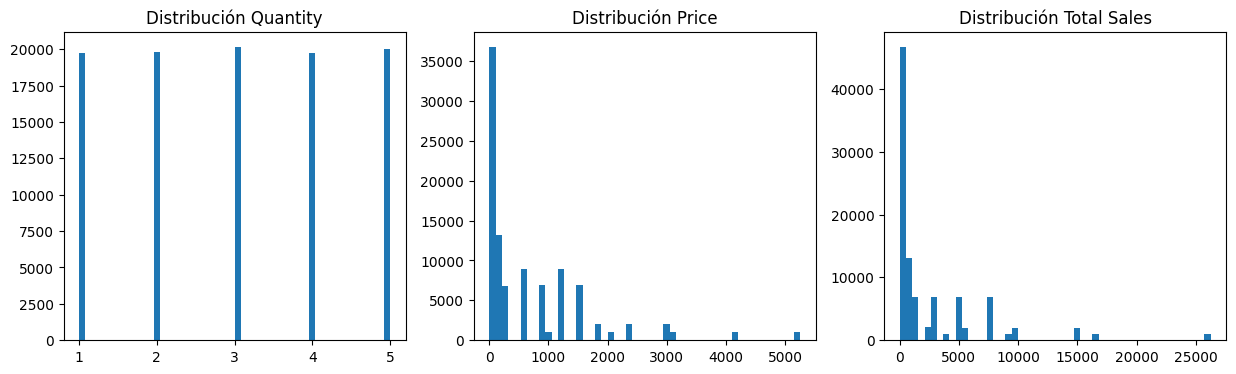

In [ ]:
# 8.1.2 Distribución de variables numéricas

fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(df_empresa["quantity"], bins=50)
axes[0].set_title("Distribución Quantity")

axes[1].hist(df_empresa["price"], bins=50)
axes[1].set_title("Distribución Price")

axes[2].hist(df_empresa["total_sales"], bins=50)
axes[2].set_title("Distribución Total Sales")

plt.show()

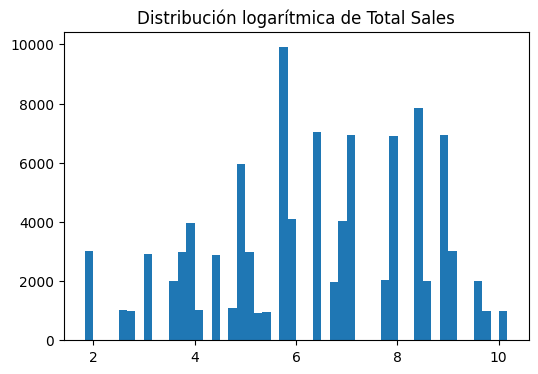

In [ ]:
# 8.1.3 Transformación logarítmica para evaluar sesgo

plt.figure(figsize=(6,4))
plt.hist(np.log1p(df_empresa["total_sales"]), bins=50)
plt.title("Distribución logarítmica de Total Sales")
plt.show()

,count
category,
Clothing,34487
Cosmetics,15097
Food & Beverage,14776
Toys,10087
Shoes,10034
Souvenir,4999
Technology,4996
Books,4981


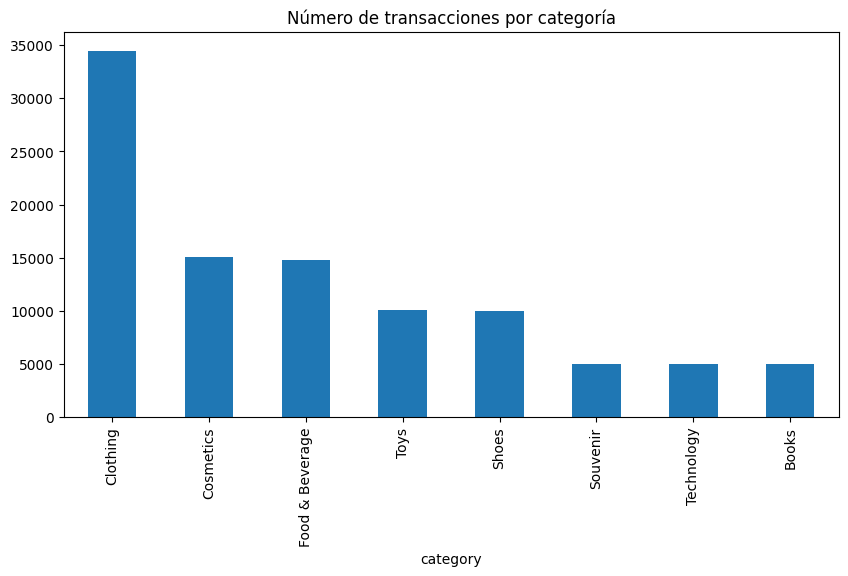

In [ ]:
# 8.1.4 Frecuencia por categoría

display(df_empresa["category"].value_counts())

# Gráfico
df_empresa["category"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Número de transacciones por categoría")
plt.show()

## 8.2 Boxplot para detectar outliers



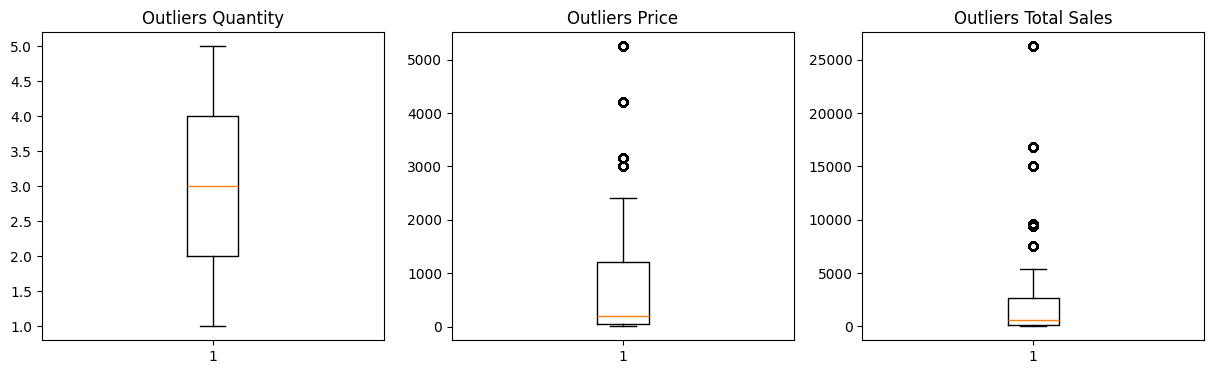

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].boxplot(df_empresa["quantity"])
axes[0].set_title("Outliers Quantity")

axes[1].boxplot(df_empresa["price"])
axes[1].set_title("Outliers Price")

axes[2].boxplot(df_empresa["total_sales"])
axes[2].set_title("Outliers Total Sales")

plt.show()

## 8.3 Análisis Bivariante

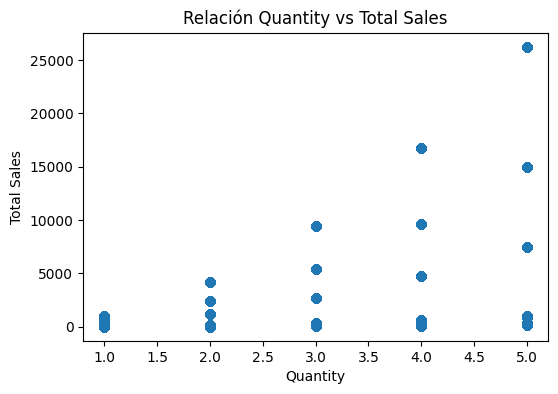

In [ ]:
# 8.3.1 Relación entre variables numéricas

plt.figure(figsize=(6,4))
plt.scatter(df_empresa["quantity"], df_empresa["total_sales"], alpha=0.3)
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.title("Relación Quantity vs Total Sales")
plt.show()

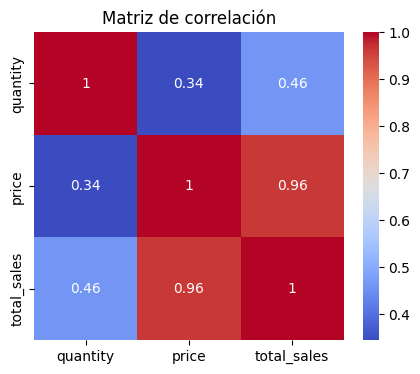

In [ ]:
# 8.3.2 Correlación entre variables numéricas

corr = df_empresa[["quantity", "price", "total_sales"]].corr()

import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

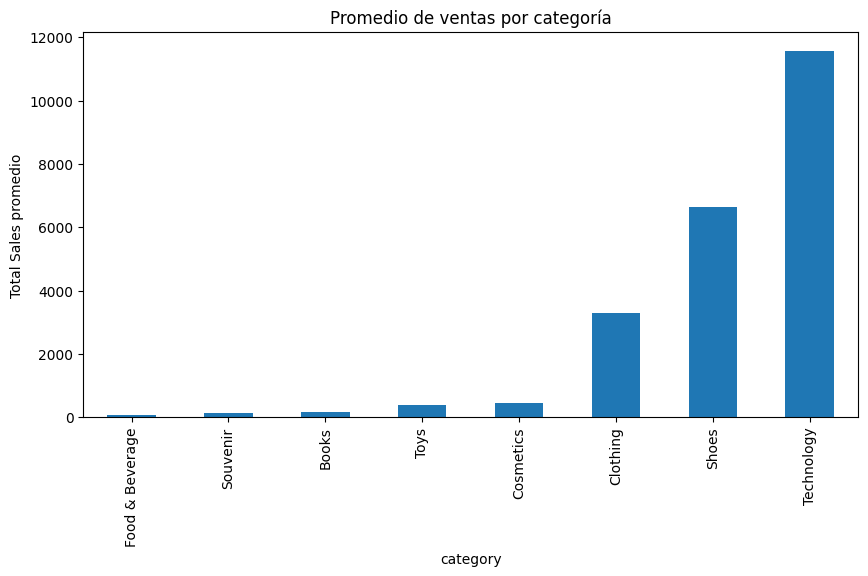

In [ ]:
# 8.3.3 Comparación de ventas por categoría

ventas_cat = df_empresa.groupby("category")["total_sales"].mean().sort_values()

ventas_cat.plot(kind="bar", figsize=(10,5))
plt.title("Promedio de ventas por categoría")
plt.ylabel("Total Sales promedio")
plt.show()

## 8.4 Análisis Temporal

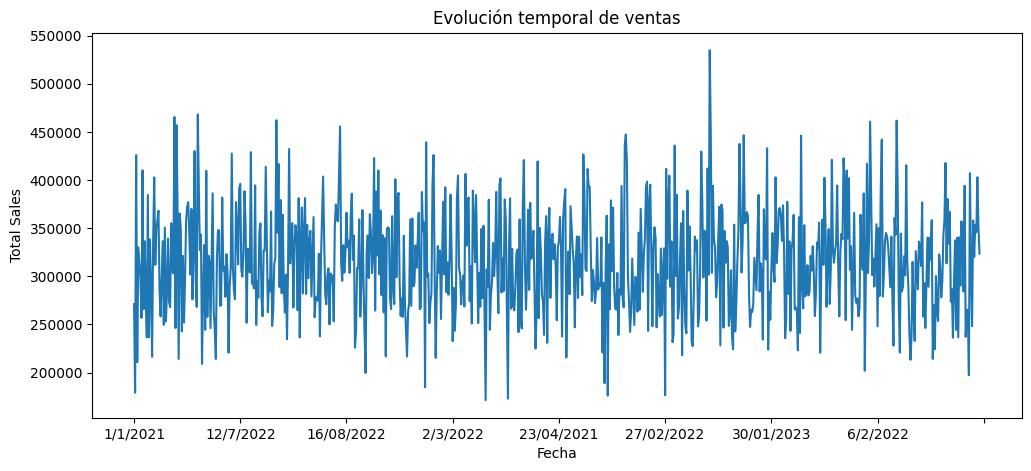

In [ ]:
# 8.4.1 Serie temporal agregada diaria

df_temp = df_empresa.groupby("invoice_date")["total_sales"].sum()

plt.figure(figsize=(12,5))
df_temp.plot()
plt.title("Evolución temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Total Sales")
plt.show()

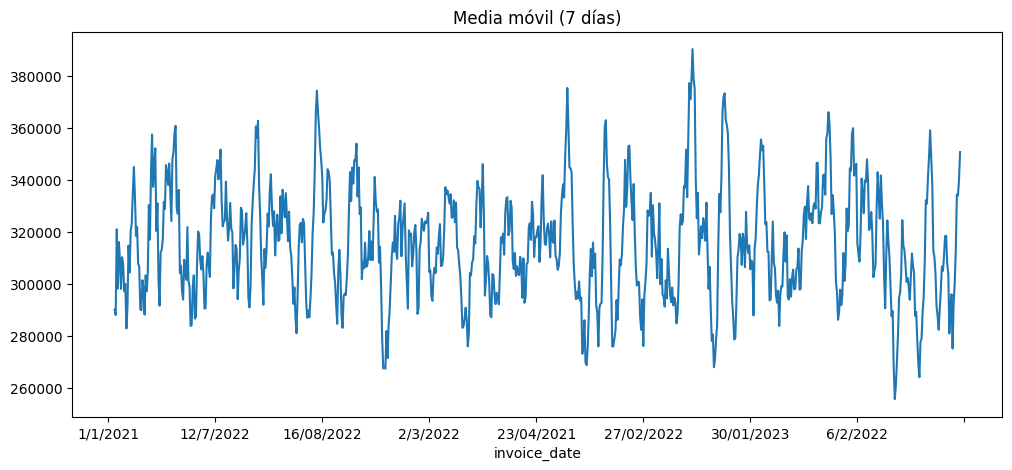

In [ ]:
# 8.4.2 Media móvil para observar tendencia

df_temp.rolling(window=7).mean().plot(figsize=(12,5))
plt.title("Media móvil (7 días)")
plt.show()


## 8.5 Serie temporal por categoría (Top 3)


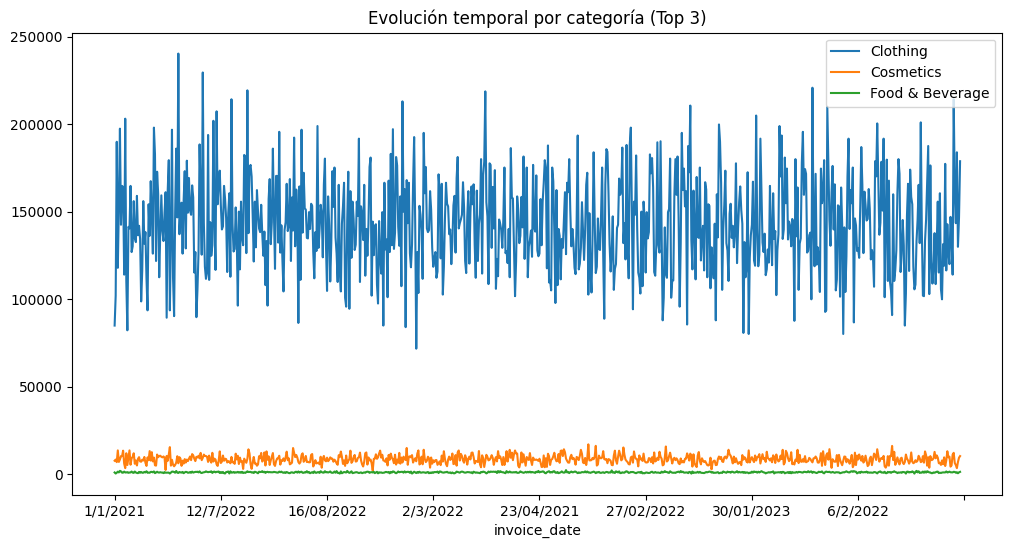

In [ ]:
top_cat = df_empresa["category"].value_counts().head(3).index

plt.figure(figsize=(12,6))

for cat in top_cat:
    serie = df_empresa[df_empresa["category"] == cat] \
                .groupby("invoice_date")["total_sales"].sum()
    serie.plot(label=cat)

plt.legend()
plt.title("Evolución temporal por categoría (Top 3)")
plt.show()

## 8.6 CONCLUSIONES DEL EDA

Principales hallazgos:

- La distribución de ventas presenta asimetría, lo que sugiere
  el uso de transformaciones para mejorar el modelado.

- Existe alta variabilidad entre categorías, lo que justifica
  el modelado independiente por tipo de producto.

- La relación entre cantidad y ventas es coherente, validando
  la calidad del dataset.

- El comportamiento temporal confirma la naturaleza de serie
  temporal del problema.

- Se decide trabajar con frecuencia semanal para reducir ruido
  y mejorar la estabilidad de los modelos.


# 9. AGREGACIÓN TEMPORAL SEMANAL

En esta sección se transforman los datos transaccionales en series temporales agregadas con frecuencia semanal.

Objetivos:
- Reducir la variabilidad de los datos diarios
- Construir series temporales continuas
- Preparar los datos para modelos como SARIMA y XGBoost

La agregación se realiza por:
- semana
- categoría de producto

## 9.1 Creación de variable temporal semanal


In [ ]:
df_empresa["week"] = df_empresa["invoice_date"].dt.to_period("W").apply(lambda r: r.start_time)

print("Variable 'week' creada correctamente.")
display(df_empresa[["invoice_date", "week"]].head())

Variable 'week' creada correctamente.


,invoice_date,week
0,2022-05-08,2022-05-02
1,2021-12-12,2021-12-06
2,2021-09-11,2021-09-06
8,2021-04-11,2021-04-05
14,2022-03-06,2022-02-28


## 9.2 Agregación semanal por categoría


In [ ]:
df_semanal = df_empresa.groupby(["week", "category"]).agg({
    "quantity": "sum",
    "total_sales": "sum"
}).reset_index()

print("Dataset agregado:")
display(df_semanal.head())

Dataset agregado:


,week,category,quantity,total_sales
0,2020-12-28,Books,63,3590.55
1,2020-12-28,Clothing,261,281174.96
2,2020-12-28,Cosmetics,139,18906.90
3,2020-12-28,Food & Beverage,178,3608.70
4,2020-12-28,Shoes,112,258073.10


## 9.3 Relleno de semanas faltantes (series continuas)


In [ ]:
df_semanal_completo = []

categorias = df_semanal["category"].unique()

for cat in categorias:

    df_cat = df_semanal[df_semanal["category"] == cat].copy()
    df_cat = df_cat.set_index("week")

    # Crear rango completo de semanas
    rango_fechas = pd.date_range(
        start=df_cat.index.min(),
        end=df_cat.index.max(),
        freq="W-MON"
    )

    # Reindexar para completar semanas faltantes
    df_cat = df_cat.reindex(rango_fechas)

    # Rellenar valores faltantes con 0
    df_cat["category"] = cat
    df_cat["quantity"] = df_cat["quantity"].fillna(0)
    df_cat["total_sales"] = df_cat["total_sales"].fillna(0)

    df_cat = df_cat.reset_index().rename(columns={"index": "week"})

    df_semanal_completo.append(df_cat)

df_semanal = pd.concat(df_semanal_completo, ignore_index=True)

## 9.4 Ordenar y asegurar formato correcto


In [ ]:
df_semanal["week"] = pd.to_datetime(df_semanal["week"])
df_semanal = df_semanal.sort_values(["category", "week"]).reset_index(drop=True)

print("Dataset semanal final:")
display(df_semanal.head())

Dataset semanal final:


,week,category,quantity,total_sales
0,2020-12-28,Books,63.0,3590.55
1,2021-01-04,Books,112.0,6423.60
2,2021-01-11,Books,26.0,1212.00
3,2021-01-18,Books,0.0,0.00
4,2021-01-25,Books,0.0,0.00


## 9.5 Verificación del dataset final

In [ ]:
print("Dimensiones:", df_semanal.shape)

print("\nValores nulos:")
print(df_semanal.isnull().sum())

print("\nNúmero de categorías únicas:")
print(df_semanal["category"].nunique())

Dimensiones: (1224, 4)

Valores nulos:
week           0
category       0
quantity       0
total_sales    0
dtype: int64

Número de categorías únicas:
8


## 9.6 Visualización de una categoría de ejemplo


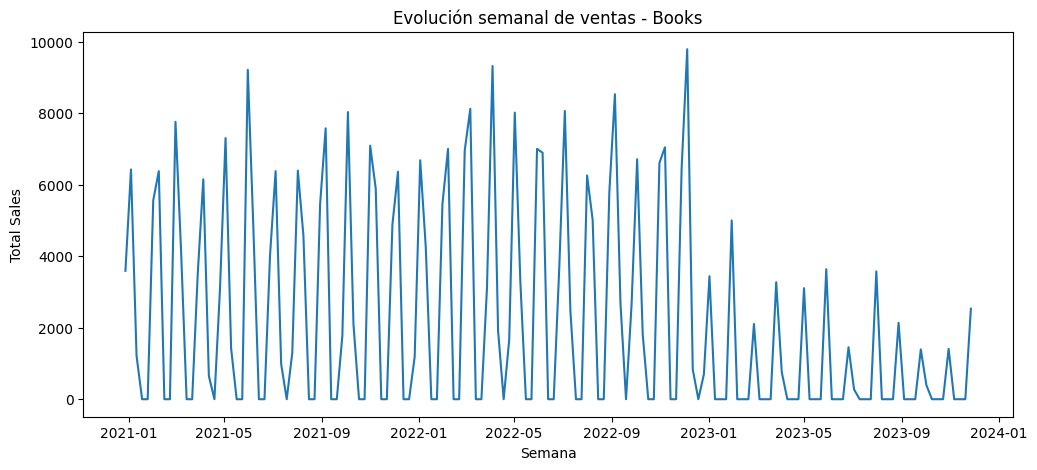

In [ ]:
categoria_ejemplo = df_semanal["category"].unique()[0]
df_plot = df_semanal[df_semanal["category"] == categoria_ejemplo]

plt.figure(figsize=(12,5))
plt.plot(df_plot["week"], df_plot["total_sales"])
plt.title(f"Evolución semanal de ventas - {categoria_ejemplo}")
plt.xlabel("Semana")
plt.ylabel("Total Sales")
plt.show()

Se construyeron series temporales semanales por categoría de
producto, garantizando continuidad mediante el relleno de
semanas sin ventas con valor cero. Esta transformación permite
preparar los datos adecuadamente para la aplicación de modelos
de series temporales y aprendizaje automático.

#10. Modelos

## 10.3. Modelo de Regresión Lineal

**Justificación del algoritmo:**
La Regresión Lineal es un modelo base interpretable que permite cuantificar la relación entre el tiempo (variable continua) y la cantidad vendida por categoría de producto. Al incorporar el tipo de producto mediante OneHotEncoding, el modelo aprende una tendencia lineal independiente por categoría.

Es un punto de partida sólido y su interpretabilidad facilita la validación de resultados con el negocio.

In [ ]:
# Variable independiente: tiempo escalado + categoría codificada
X = np.hstack([
    df_agg[['tiempo_scaled']].values,
    encoder.transform(df_agg[['tipo_producto']])
])

# Variable objetivo: cantidad en escala log
y = df_agg['cantidad_log'].values

print('Shape X:', X.shape)
print('Shape y:', y.shape)

División Train / Test (Temporal)

Dividimos el dataset respetando el orden temporal: el **80%** más antiguo para entrenamiento y el **20%** más reciente para test. Esto evita el data leakage que ocurriría con una división aleatoria en datos de series temporales.

In [ ]:
# División temporal: 80% train, 20% test
tiempos_unicos = sorted(df_agg['tiempo'].unique())
split_idx = int(len(tiempos_unicos) * 0.8)
tiempo_corte = tiempos_unicos[split_idx]

mask_train = df_agg['tiempo'] <= tiempo_corte
mask_test  = df_agg['tiempo']  > tiempo_corte

X_train, X_test = X[mask_train], X[mask_test]
y_train, y_test = y[mask_train], y[mask_test]

print(f'Tiempo de corte: {tiempo_corte}')
print(f'Registros en train: {X_train.shape[0]}')
print(f'Registros en test:  {X_test.shape[0]}')

Entrenamiento

In [ ]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

Evaluación y Métricas

Evaluamos el modelo sobre el conjunto de test con tres métricas:
- **MAE** (Mean Absolute Error): error medio absoluto
- **RMSE** (Root Mean Squared Error): penaliza errores grandes
- **R²**: proporción de varianza explicada (1.0 = perfecto, 0 = no mejor que la media)

In [ ]:
# Predicciones sobre test
y_pred_lr = modelo.predict(X_test)

# Métricas en escala log
mae_lr   = mean_absolute_error(y_test, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr    = r2_score(y_test, y_pred_lr)

print('=== Métricas Regresión Lineal (escala log) ===')
print(f'MAE  : {mae_lr:.4f}')
print(f'RMSE : {rmse_lr:.4f}')
print(f'R2   : {r2_lr:.4f}')

# Métricas en escala original (invertir log-transform)
y_pred_orig = np.expm1(y_pred_lr)
y_test_orig = np.expm1(y_test)
mae_orig  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
print('\n=== Métricas Regresión Lineal (escala original) ===')
print(f'MAE  : {mae_orig:.2f} unidades')
print(f'RMSE : {rmse_orig:.2f} unidades')


Predicción Futura (próximos 3 meses)

In [ ]:
from sklearn.linear_model import LinearRegression

# Lista para almacenar las predicciones de cada producto
all_future_predictions = []
productos = df_agg['tipo_producto'].unique()
forecast_steps = 6

# Iterar sobre cada producto para entrenar un modelo y predecir individualmente
for producto in productos:
    df_p = df_agg[df_agg['tipo_producto'] == producto].copy()

    if len(df_p) < 2: # Se necesitan al menos 2 puntos para una regresión lineal simple
        continue

    X = df_p[['tiempo_scaled']].values
    y = df_p['cantidad_log'].values

    # Entrenar un nuevo modelo de Regresión Lineal para este producto
    modelo_prod = LinearRegression()
    modelo_prod.fit(X, y)

    ultimo_tiempo_prod = df_p['tiempo'].max()

    futuros_tiempos_raw = np.array([ultimo_tiempo_prod + i for i in range(1, forecast_steps + 1)])

    futuros_tiempos_scaled = scaler_tiempo.transform(futuros_tiempos_raw.reshape(-1, 1))

    predicciones_log = modelo_prod.predict(futuros_tiempos_scaled)
    predicciones_orig = np.expm1(predicciones_log).clip(0)


    df_pred_prod = pd.DataFrame({
        'tiempo': futuros_tiempos_raw,
        'tiempo_scaled': futuros_tiempos_scaled.flatten(),
        'tipo_producto': producto,
        'cantidad_predicha': predicciones_orig
    })
    all_future_predictions.append(df_pred_prod)


df_futuro = pd.concat(all_future_predictions, ignore_index=True)

df_futuro.head(10)

Visualización (Top 10 Categorías por Volumen)

In [ ]:
def tiempo_a_fecha(t):
    """Convierte tiempo=año*12+mes a string 'YYYY-MM'."""
    anio = t // 12
    mes  = t % 12
    if mes == 0:
        mes = 12
        anio -= 1
    return pd.Timestamp(year=anio, month=mes, day=1)

top10_cats = (
    df_agg.groupby('tipo_producto')['cantidad'].sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

fig, axes = plt.subplots(5, 2, figsize=(16, 25))
axes = axes.flatten()

for idx, producto in enumerate(top10_cats):
    subset_real = df_agg[df_agg['tipo_producto'] == producto].copy()
    subset_pred = df_futuro[df_futuro['tipo_producto'] == producto].copy()

    # Convertir 'tiempo' a formato de fecha para el eje X
    subset_real['fecha_mes'] = subset_real['tiempo'].apply(tiempo_a_fecha).dt.strftime('%Y-%m')
    subset_pred['fecha_mes'] = subset_pred['tiempo'].apply(tiempo_a_fecha).dt.strftime('%Y-%m')

    # Asegurar el orden cronológico para el gráfico
    subset_real = subset_real.sort_values(by='fecha_mes')
    subset_pred = subset_pred.sort_values(by='fecha_mes')

    ax = axes[idx]
    ax.plot(subset_real['fecha_mes'], np.expm1(subset_real['cantidad_log']), # Usar fecha_mes
            label='Real', marker='o', markersize=3)
    ax.plot(subset_pred['fecha_mes'], subset_pred['cantidad_predicha'], # Usar fecha_mes
            label='Prediccion', linestyle='--', marker='s', markersize=4, color='tomato')
    ax.set_title(producto)
    ax.set_xlabel('Fecha (Año-Mes)') # Cambiar etiqueta del eje X
    ax.set_ylabel('Cantidad')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45) # Rotar y alinear etiquetas

plt.suptitle('Regresion Lineal: Ventas Reales vs Prediccion Futura (Top 10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Interpretación

La regresión lineal captura tendencias generales de crecimiento o descenso por categoría. Las categorías con mayor R² presentan una tendencia temporal clara y estable, mientras que aquellas con R² bajo exhiben mayor volatilidad o comportamiento no lineal.

**Limitación principal:** El modelo asume una relación lineal con el tiempo y no captura estacionalidad ni patrones complejos.

Los resultados gráficos muestran que la regresión lineal captura adecuadamente la tendencia general de crecimiento en las distintas categorías de producto. Sin embargo, se observa que el modelo tiende a sobreestimar las ventas futuras, especialmente en categorías con alta variabilidad.

Esto se debe a que la regresión lineal asume una relación estrictamente lineal con el tiempo, lo que impide capturar fluctuaciones, estacionalidad o comportamientos no lineales presentes en los datos reales.

En consecuencia, aunque el modelo resulta útil como línea base por su interpretabilidad, presenta limitaciones claras para modelar dinámicas complejas, lo cual justifica el uso de modelos más avanzados en etapas posteriores del proyecto.

Comparación entre Regresión Lineal y ARIMA

In [ ]:
# La comparación completa de los tres modelos (Ridge, ARIMA, Random Forest)
# se presenta en la Sección 5.3 una vez entrenado el Random Forest.
print(f'Métricas Ridge  — MAE: {mae_orig:.2f} | RMSE: {rmse_orig:.2f} | R²: {r2_lr:.4f}')
print(f'Métricas ARIMA  — MAE: {resumen_arima["MAE"].mean():.2f} | RMSE: {resumen_arima["RMSE"].mean():.2f}')
print('→ Comparación final de los 3 modelos disponible en Sección 5.3')

Modelo Avanzado: Random Forest Regressor (Ensemble) **(Cambiar por redes neuronales o XGBoost)**

**Justificación:**
Random Forest es un modelo ensemble que combina múltiples árboles de decisión entrenados con subconjuntos aleatorios de datos y features (bagging). Sus ventajas frente a la regresión lineal son:

- Captura relaciones **no lineales** entre tiempo y ventas
- Es **robusto a outliers** y no requiere distribución normal de los residuos
- Proporciona **importancia de variables**, útil para interpretación de negocio
- Permite **ajuste de hiperparámetros** con `GridSearchCV` y validación cruzada temporal

Este modelo representa la extensión avanzada requerida y permite contrastar un enfoque clásico de series temporales con una técnica de aprendizaje automático más flexible

Preparación de Datos

In [ ]:

df_rf = df_agg.copy()

# Features temporales adicionales
df_rf['anio']    = (df_rf['tiempo'] - 1) // 12
df_rf['mes_num'] = ((df_rf['tiempo'] - 1) % 12) + 1

# Reutilizar el encoder global fiteado en la Sección 2
cat_encoded = encoder.transform(df_rf[['tipo_producto']])
df_cat = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(['tipo_producto']),
    index=df_rf.index
)

X_rf = pd.concat([df_rf[['tiempo_scaled', 'anio', 'mes_num']], df_cat], axis=1)
y_rf = df_rf['cantidad_log'].values

print('Shape X_rf:', X_rf.shape)

Ajuste de Hiperparámetros con GridSearchCV

In [ ]:
# División temporal 80/20 — mismo corte que Regresión Lineal
X_rf_train = X_rf[mask_train]
X_rf_test  = X_rf[mask_test]
y_rf_train = y_rf[mask_train]
y_rf_test  = y_rf[mask_test]

print(f'Tiempo de cort: {tiempo_corte}')
print(f'Train RF: {X_rf_train.shape[0]} registros | Test RF: {X_rf_test.shape[0]} registros')

# GridSearchCV con validación cruzada temporal
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=3)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_rf_train, y_rf_train)

print('Mejores hiperparámetros:', grid_search.best_params_)
print(f'Mejor MAE (CV): {-grid_search.best_score_:.4f}')

Evaluación y Comparación con Regresión Lineal

In [ ]:
modelo_rf = grid_search.best_estimator_

y_rf_pred = modelo_rf.predict(X_rf_test)

mae_rf  = mean_absolute_error(y_rf_test, y_rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_rf_test, y_rf_pred))
r2_rf   = r2_score(y_rf_test, y_rf_pred)

print('=== Comparacion de Modelos (escala log) ===')
comparacion = pd.DataFrame({
    'Modelo': ['Regresion Lineal', 'ARIMA', 'Random Forest'],
    'MAE':  [round(mae_lr, 4), round(resumen_arima['MAE'].mean(), 4), round(mae_rf, 4)],
    'RMSE': [round(rmse_lr, 4), round(resumen_arima['RMSE'].mean(), 4), round(rmse_rf, 4)],
    'R2':   [round(r2_lr, 4), np.nan, round(r2_rf, 4)]
})
print(comparacion.to_string(index=False))

Visualizaciones: Predicho vs Real — Random Forest

---

Se presentan tres tipos de visualización para evaluar la calidad del modelo:
1. **Scatter plot** predicho vs rea
2. **Serie temporal** por categoría — real vs predicho en el conjunto de test
3. **Distribución de residuales** (error = real − predicho)

In [ ]:
# ── 1. Scatter plot global: Predicho vs Real (escala original) ──────────
y_rf_orig      = np.expm1(y_rf_test)
y_rf_pred_orig = np.expm1(y_rf_pred).clip(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(y_rf_orig, y_rf_pred_orig, alpha=0.4, s=20, color='steelblue')
lim = max(y_rf_orig.max(), y_rf_pred_orig.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('Real (unidades)')
ax.set_ylabel('Predicho (unidades)')
ax.set_title('Random Forest — Predicho vs Real (escala original)')
ax.legend()

# Residuales
residuales = y_rf_orig - y_rf_pred_orig
ax2 = axes[1]
ax2.hist(residuales, bins=50, color='steelblue', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', lw=1.5)
ax2.set_xlabel('Error (Real − Predicho)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Residuales — Random Forest')

plt.tight_layout()
plt.show()

print(f'Sesgo medio (bias): {residuales.mean():.4f}')
print(f'Std residuales    : {residuales.std():.4f}')

In [ ]:
def tiempo_a_fecha(t):
    """Convierte tiempo=año*12+mes a string 'YYYY-MM'."""
    anio = t // 12
    mes  = t % 12
    if mes == 0:
        mes = 12
        anio -= 1
    return pd.Timestamp(year=anio, month=mes, day=1)

In [ ]:
# ── 2. Serie temporal mensual: Real vs Predicho por categoría (Top 10) ──
df_rf_test_eval = df_rf[mask_test].copy()
df_rf_test_eval['y_real']    = np.expm1(y_rf_test)
df_rf_test_eval['y_pred']    = np.expm1(y_rf_pred).clip(0)
df_rf_test_eval['error_abs'] = np.abs(df_rf_test_eval['y_real'] - df_rf_test_eval['y_pred'])
df_rf_test_eval['fecha']     = df_rf_test_eval['tiempo'].apply(tiempo_a_fecha)

top10_rf = (
    df_rf.groupby('tipo_producto')['cantidad']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

fig, axes = plt.subplots(5, 2, figsize=(16, 26))
axes = axes.flatten()

for idx, producto in enumerate(top10_rf):
    sub = df_rf_test_eval[df_rf_test_eval['tipo_producto'] == producto].sort_values('fecha')
    ax  = axes[idx]
    ax.plot(sub['fecha'], sub['y_real'], marker='o', ms=4,
            label='Real', color='seagreen', lw=1.5)
    ax.plot(sub['fecha'], sub['y_pred'], marker='s', ms=4,
            linestyle='--', label='Predicho (RF)', color='tomato', lw=1.5)
    mae_cat = sub['error_abs'].mean()
    ax.set_title(f'{producto}  (MAE={mae_cat:.1f})', fontsize=9)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Unidades vendidas')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('Random Forest — Real vs Predicho por Mes (Top 10 categorías)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Importancia de Variables

In [ ]:
feature_names = list(X_rf.columns)
importancias = pd.Series(modelo_rf.feature_importances_, index=feature_names)
top_features = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Importancia de Variables — Random Forest (Top 15)')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('tiempo_scaled y mes_num capturan la dinamica temporal,')
print('las variables de categoria reflejan el impacto diferencial por tipo de producto.')

Interpretación


Random Forest permite capturar relaciones no lineales entre el tiempo y la cantidad vendida, lo que le otorga una ventaja frente a la regresión lineal cuando las series presentan patrones más complejos o comportamientos no estrictamente crecientes. Además, al incorporar variables temporales y la categoría del producto, el modelo puede aprender diferencias específicas entre segmentos sin imponer una forma funcional fija.

En comparación con la regresión lineal, Random Forest suele ofrecer mejor desempeño predictivo cuando existen interacciones, cambios abruptos o heterogeneidad entre categorías. Frente a ARIMA, presenta la ventaja de integrar múltiples variables explicativas y no depender exclusivamente de la estructura autorregresiva de una serie univariada.

La interpretación de importancia de variables permite identificar qué factores influyen más en la predicción, reforzando la utilidad del modelo no solo desde la precisión, sino también desde la comprensión del comportamiento de ventas por categoría.

#11. Uso de ChatGPT como herramienta de apoyo y comunicación

**Justificación:** Se incorpora ChatGPT como herramienta complementaria para la **interpretación y comunicación de resultados** obtenidos a partir de los modelos predictivos. Su función no consiste en generar predicciones ni sustituir los modelos estadísticos o de machine learning, sino en **traducir métricas técnicas y hallazgos cuantitativos en explicaciones comprensibles para usuarios no especializados.**

Esta integración aporta valor al sistema por tres razones principales:

*   Facilita la interpretación de métricas como **MAE, RMSE y R².**
*   Mejora la comunicación de resultados hacia usuarios con perfil no técnico.
*   Refuerza el enfoque práctico del TFM, orientado a pequeñas y medianas empresas.


##7.1 Configuración de la librería y autenticación

En esta versión se implementa una **simulación funcional del comportamiento esperado de ChatGPT**, evitando dependencia de cuota o facturación en el entorno de desarrollo.

In [ ]:
# En la versión simulada no es obligatorio usar la API de OpenAI
# Se mantiene una estructura compatible con una futura integración real

import os

##7.2 Función para interpretar resultados de modelos

In [ ]:
def interpretar_resultados_modelo(modelo, mae, rmse, r2=None, contexto="predicción de ventas por categoría"):
    texto = f"""
=== Interpretación simulada tipo ChatGPT ===

Modelo: {modelo}
Contexto: {contexto}

1. Interpretación técnica breve:
El modelo presenta un MAE de {mae:.2f} y un RMSE de {rmse:.2f}.
"""

    if r2 is not None:
        texto += f" El valor de R² es {r2:.2f}, lo que permite evaluar la proporción de varianza explicada por el modelo.\n"
    else:
        texto += " En este caso no se dispone de R², ya que el modelo evaluado no utiliza esta métrica como referencia principal.\n"

    texto += f"""
2. Explicación sencilla orientada a negocio:
El modelo {modelo} permite estimar el comportamiento futuro de las ventas con un nivel razonable de precisión, sirviendo como apoyo para planificación, control de stock y toma de decisiones.

3. Limitación principal del modelo:
Aunque ofrece información útil, este modelo puede no capturar completamente cambios bruscos, estacionalidad compleja o relaciones altamente no lineales presentes en los datos.
"""

    return texto

##7.3 Interpretación automática de la Regresión Lineal

In [ ]:
texto_lr = interpretar_resultados_modelo(
    modelo="Regresión Lineal",
    mae=mae_orig,
    rmse=rmse_orig,
    r2=r2_lr,
    contexto="forecasting de ventas de productos de e-commerce"
)

print("=== Interpretación tipo ChatGPT (simulada): Regresión Lineal ===")
print(texto_lr)

##7.4 Interpretación automática de ARIMA

In [ ]:
texto_arima = interpretar_resultados_modelo(
    modelo="ARIMA (1,1,1)",
    mae=resumen_arima["MAE"].mean(),
    rmse=resumen_arima["RMSE"].mean(),
    r2=None,
    contexto="forecasting temporal de ventas por categoría"
)

print("=== Interpretación ChatGPT: ARIMA ===")
print(texto_arima)

##7.5 Interpretación automática de Random Forest

In [ ]:
texto_rf = interpretar_resultados_modelo(
    modelo="Random Forest",
    mae=mae_rf,
    rmse=rmse_rf,
    r2=r2_rf,
    contexto="forecasting de ventas de productos de e-commerce"
)

print("=== Interpretación ChatGPT: Random Forest ===")
print(texto_rf)

##7.6 Almacenamiento de interpretaciones

In [ ]:
with open("interpretacion_modelos.txt", "w", encoding="utf-8") as f:
    f.write("=== Regresión Lineal ===\n")
    f.write(texto_lr + "\n\n")
    f.write("=== ARIMA ===\n")
    f.write(texto_arima + "\n\n")
    f.write("=== Random Forest ===\n")
    f.write(texto_rf + "\n")

##7.7 Integración en Streamlit para mostrar la interpretación

In [ ]:
# Instalar Streamlit si no está instalado
!pip install streamlit

import streamlit as st
import pandas as pd

# -------------------------------
# Función simulada tipo ChatGPT
# -------------------------------

def interpretar_streamlit(modelo, mae, rmse, r2=None):
    texto = f"""
### Interpretación tipo ChatGPT

**Modelo seleccionado:** {modelo}

#### 1. Interpretación técnica
El modelo presenta un **MAE de {mae:.2f}** y un **RMSE de {rmse:.2f}**.
"""

    if r2 is not None:
        texto += f" Además, el **R² es {r2:.2f}**, lo que permite evaluar la proporción de varianza explicada por el modelo.\n"
    else:
        texto += " En este caso no se dispone de **R²**, ya que este modelo no utiliza dicha métrica como referencia principal.\n"

    texto += f"""
#### 2. Explicación sencilla para negocio
El modelo **{modelo}** permite estimar el comportamiento futuro de las ventas con un nivel razonable de precisión, sirviendo como apoyo para planificación, control de inventario y toma de decisiones.

#### 3. Limitación principal
Aunque ofrece información útil, este modelo puede no capturar completamente cambios bruscos, estacionalidad compleja o relaciones altamente no lineales presentes en los datos.
"""

    return texto


# -------------------------------
# Configuración de página
# -------------------------------

st.set_page_config(page_title="Interpretación de Modelos", layout="wide")

st.title("Interpretación automática de resultados")
st.write(
    "Esta sección muestra una interpretación tipo ChatGPT para facilitar la comprensión "
    "de los resultados de los modelos predictivos."
)

# -------------------------------
# Diccionario de métricas
# Usa aquí las métricas reales ya calculadas
# -------------------------------

metricas_modelos = {
    "Regresión Lineal": {
        "MAE": mae_orig,
        "RMSE": rmse_orig,
        "R2": r2_lr
    },
    "ARIMA": {
        "MAE": resumen_arima["MAE"].mean(),
        "RMSE": resumen_arima["RMSE"].mean(),
        "R2": None
    },
    "Random Forest": {
        "MAE": mae_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    }
}

# -------------------------------
# Selector de modelo
# -------------------------------

modelo_seleccionado = st.selectbox(
    "Selecciona el modelo a interpretar",
    list(metricas_modelos.keys())
)

mae_val = metricas_modelos[modelo_seleccionado]["MAE"]
rmse_val = metricas_modelos[modelo_seleccionado]["RMSE"]
r2_val = metricas_modelos[modelo_seleccionado]["R2"]

# -------------------------------
# Mostrar métricas en tarjetas
# -------------------------------

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("MAE", f"{mae_val:.2f}")

with col2:
    st.metric("RMSE", f"{rmse_val:.2f}")

with col3:
    if r2_val is not None:
        st.metric("R²", f"{r2_val:.2f}")
    else:
        st.metric("R²", "N/A")

# -------------------------------
# Botón para generar interpretación
# -------------------------------

if st.button("Generar interpretación"):
    with st.spinner("Generando interpretación..."):
        texto = interpretar_streamlit(
            modelo=modelo_seleccionado,
            mae=mae_val,
            rmse=rmse_val,
            r2=r2_val
        )

    st.markdown("---")
    st.chat_message("assistant").markdown(texto)

# -------------------------------
# Tabla opcional de métricas
# -------------------------------

st.markdown("---")
st.subheader("Resumen comparativo de métricas")

tabla_metricas = pd.DataFrame(metricas_modelos).T.reset_index()
tabla_metricas.columns = ["Modelo", "MAE", "RMSE", "R2"]

st.dataframe(tabla_metricas, use_container_width=True)

En la aplicación desarrollada con Streamlit se incorporó un módulo de interpretación automática de resultados, orientado a traducir métricas técnicas en explicaciones comprensibles para el usuario final. Esta funcionalidad actúa como una capa complementaria de comunicación, mejorando la accesibilidad del sistema sin intervenir en el proceso de modelado predictivo.

##7.8 Interpretación metodológica

La incorporación de ChatGPT en el sistema se plantea como una **capa de apoyo interpretativo**, orientada a facilitar la lectura de resultados y la comunicación con el usuario final. En este sentido, no reemplaza el proceso de modelado, sino que complementa la aplicación al convertir métricas y predicciones en explicaciones comprensibles.

En esta implementación, la funcionalidad se presenta mediante una **simulación estructurada del comportamiento esperado**, con el fin de mantener la lógica del sistema sin depender de restricciones externas de cuota o facturación. Esto permite demostrar la viabilidad de la integración dentro del MVP y su valor práctico en contextos empresariales donde la interpretabilidad resulta tan importante como la precisión predictiva

La simulación implementada puede ser reemplazada posteriormente por una integración real con la API de OpenAI, manteniendo la misma estructura funcional del sistema.